In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load the datasets
# Update this path to your folder location
path = "C:/ProgramData/MySQL/MySQL Server 8.0/Uploads/"

orders = pd.read_csv(path + "olist_orders_dataset.csv")
order_items = pd.read_csv(path + "olist_order_items_dataset.csv")
customers = pd.read_csv(path + "olist_customers_dataset.csv")
payments = pd.read_csv(path + "olist_order_payments_dataset.csv")
products = pd.read_csv(path + "olist_products_dataset.csv")
sellers = pd.read_csv(path + "olist_sellers_dataset.csv")
category_translation = pd.read_csv(path + "product_category_name_translation.csv")

print("Datasets loaded successfully!")
print(f"\nOrders: {len(orders):,} rows")
print(f"Order Items: {len(order_items):,} rows")
print(f"Customers: {len(customers):,} rows")
print(f"Payments: {len(payments):,} rows")
print(f"Products: {len(products):,} rows")
print(f"Sellers: {len(sellers):,} rows")
print(f"Categories: {len(category_translation):,} rows")

Datasets loaded successfully!

Orders: 99,441 rows
Order Items: 112,650 rows
Customers: 99,441 rows
Payments: 103,886 rows
Products: 32,951 rows
Sellers: 3,095 rows
Categories: 71 rows


In [5]:
# Explore the orders dataset
print("=== ORDERS DATASET ===\n")
print("First 5 rows:")
display(orders.head())

print("\nData types:")
print(orders.dtypes)

print("\nMissing values:")
print(orders.isnull().sum())

print("\nOrder status distribution:")
print(orders['order_status'].value_counts())

=== ORDERS DATASET ===

First 5 rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



Data types:
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

Missing values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Order status distribution:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [7]:
# Convert date columns to datetime
date_columns = ['order_purchase_timestamp', 'order_approved_at', 
                'order_delivered_carrier_date', 'order_delivered_customer_date',
                'order_estimated_delivery_date']

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

# Create useful columns
orders['delivery_days'] = (orders['order_delivered_customer_date'] - 
                           orders['order_purchase_timestamp']).dt.days

orders['is_late'] = orders['order_delivered_customer_date'] > orders['order_estimated_delivery_date']

# Extract month and year for trend analysis
orders['order_month'] = orders['order_purchase_timestamp'].dt.to_period('M')

print("Date conversion complete!")
print(f"\nAverage delivery time: {orders['delivery_days'].mean():.1f} days")
print(f"Late delivery rate: {orders['is_late'].mean()*100:.1f}%")

Date conversion complete!

Average delivery time: 12.1 days
Late delivery rate: 7.9%


In [9]:
# Merge datasets to create a comprehensive dataframe
# Start with orders and add order items
df = orders.merge(order_items, on='order_id', how='left')

# Add customer information
df = df.merge(customers, on='customer_id', how='left')

# Add product information
df = df.merge(products, on='product_id', how='left')

# Add category translation
df = df.merge(category_translation, on='product_category_name', how='left')

# Calculate total price (product + freight)
df['total_price'] = df['price'] + df['freight_value']

print(f"Master dataframe created: {len(df):,} rows, {len(df.columns)} columns")
print(f"\nColumns: {list(df.columns)}")

Master dataframe created: 113,425 rows, 31 columns

Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_days', 'is_late', 'order_month', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'total_price']


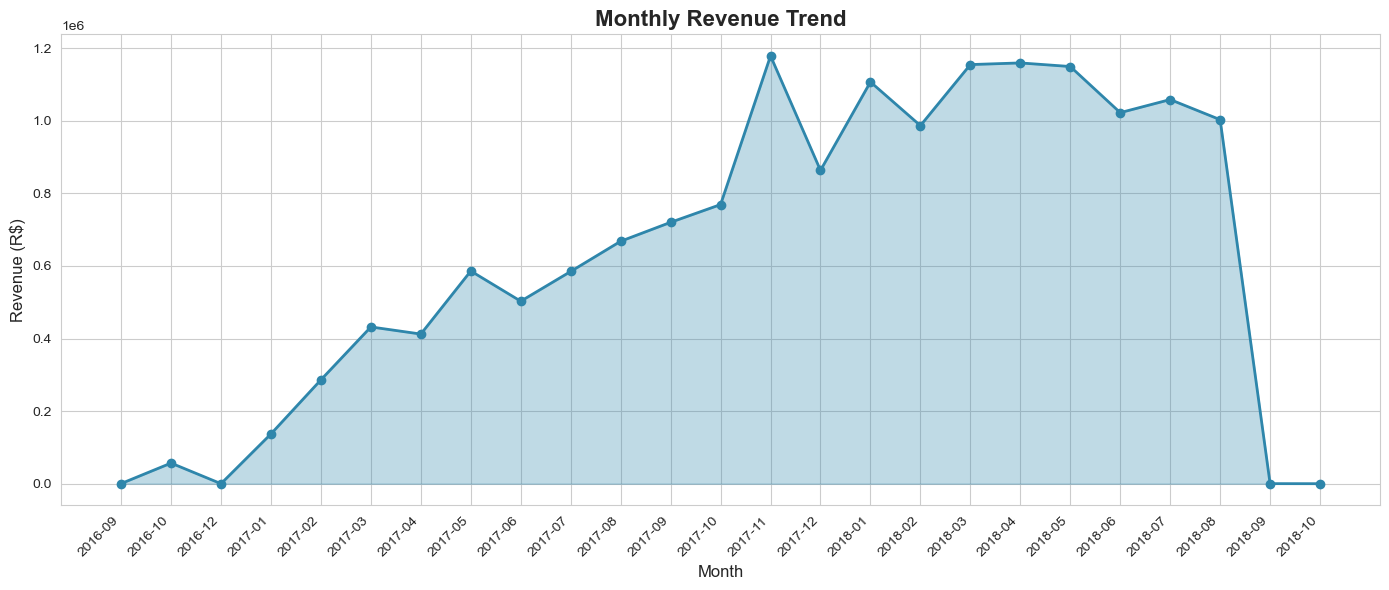

Total Revenue: R$ 15,843,553.24


In [11]:
# Monthly Revenue Trend
monthly_revenue = df.groupby('order_month')['total_price'].sum().reset_index()
monthly_revenue['order_month'] = monthly_revenue['order_month'].astype(str)

plt.figure(figsize=(14, 6))
plt.plot(monthly_revenue['order_month'], monthly_revenue['total_price'], marker='o', linewidth=2, color='#2E86AB')
plt.fill_between(monthly_revenue['order_month'], monthly_revenue['total_price'], alpha=0.3, color='#2E86AB')
plt.title('Monthly Revenue Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue (R$)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Total Revenue: R$ {df['total_price'].sum():,.2f}")

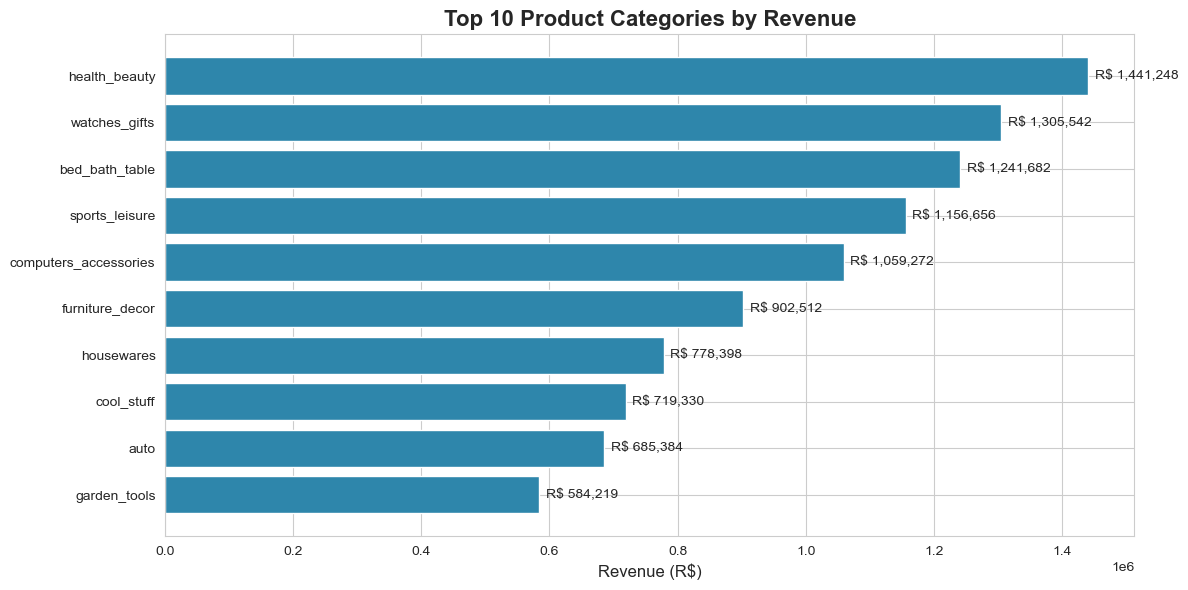

In [13]:
# Top 10 Product Categories by Revenue
category_revenue = df.groupby('product_category_name_english')['total_price'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(category_revenue.index[::-1], category_revenue.values[::-1], color='#2E86AB')
plt.title('Top 10 Product Categories by Revenue', fontsize=16, fontweight='bold')
plt.xlabel('Revenue (R$)', fontsize=12)

# Add value labels on bars
for bar, value in zip(bars, category_revenue.values[::-1]):
    plt.text(value + 10000, bar.get_y() + bar.get_height()/2, f'R$ {value:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

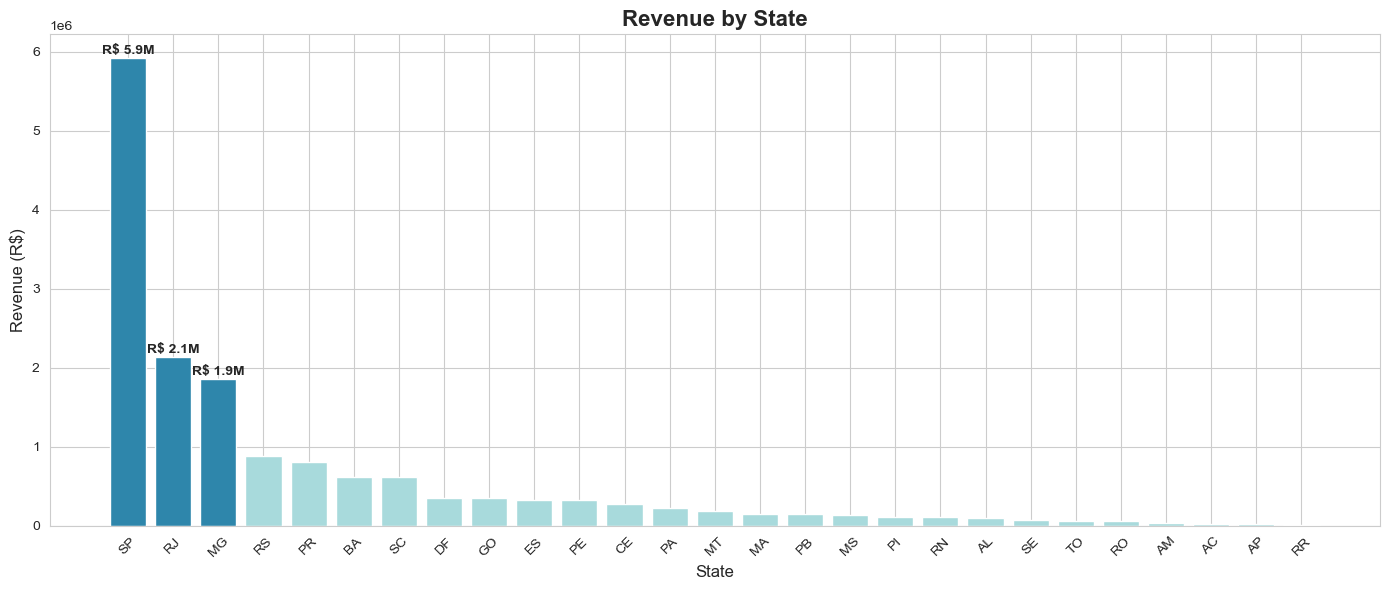

Top 5 States by Revenue:
customer_state
SP    R$ 5,921,678.12
RJ    R$ 2,129,681.98
MG    R$ 1,856,161.49
RS      R$ 885,826.76
PR      R$ 800,935.44
Name: total_price, dtype: object


In [15]:
# Revenue by State
state_revenue = df.groupby('customer_state')['total_price'].sum().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
colors = ['#2E86AB' if i < 3 else '#A8DADC' for i in range(len(state_revenue))]
bars = plt.bar(state_revenue.index, state_revenue.values, color=colors)
plt.title('Revenue by State', fontsize=16, fontweight='bold')
plt.xlabel('State', fontsize=12)
plt.ylabel('Revenue (R$)', fontsize=12)
plt.xticks(rotation=45)

# Highlight top 3 states
for i, (state, value) in enumerate(state_revenue.head(3).items()):
    plt.text(i, value + 50000, f'R$ {value/1e6:.1f}M', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("Top 5 States by Revenue:")
print(state_revenue.head().apply(lambda x: f"R$ {x:,.2f}"))

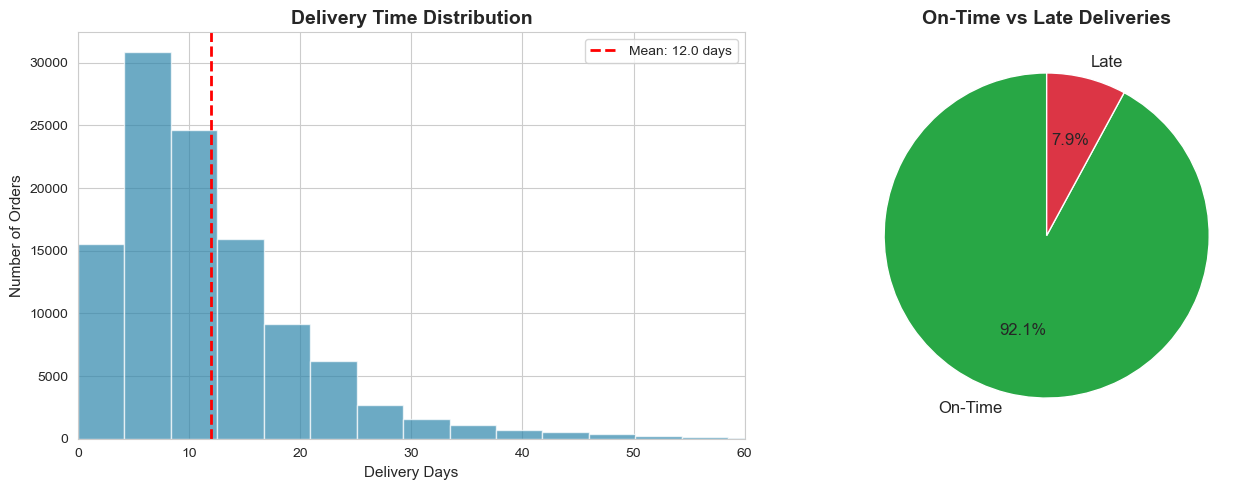

In [17]:
# Delivery Performance Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Delivery Time Distribution
delivered_orders = df[df['order_status'] == 'delivered']['delivery_days'].dropna()
axes[0].hist(delivered_orders, bins=50, color='#2E86AB', edgecolor='white', alpha=0.7)
axes[0].axvline(delivered_orders.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {delivered_orders.mean():.1f} days')
axes[0].set_title('Delivery Time Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Delivery Days', fontsize=11)
axes[0].set_ylabel('Number of Orders', fontsize=11)
axes[0].legend()
axes[0].set_xlim(0, 60)

# Plot 2: On-Time vs Late Deliveries
late_counts = df[df['order_status'] == 'delivered']['is_late'].value_counts()
labels = ['On-Time', 'Late']
colors = ['#28A745', '#DC3545']
axes[1].pie(late_counts.values, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[1].set_title('On-Time vs Late Deliveries', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [19]:
# RFM ANALYSIS - Customer Segmentation
# RFM = Recency, Frequency, Monetary

# Set the analysis date (day after last order in dataset)
analysis_date = orders['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f"Analysis Date: {analysis_date.date()}")

# Create RFM dataframe
# We need to use customer_unique_id for true customer identification
rfm = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (analysis_date - x.max()).days,  # Recency
    'order_id': 'nunique',  # Frequency
    'total_price': 'sum'  # Monetary
}).reset_index()

# Rename columns
rfm.columns = ['customer_id', 'recency', 'frequency', 'monetary']

print(f"\nTotal Unique Customers: {len(rfm):,}")
print(f"\nRFM Summary Statistics:")
display(rfm.describe())

Analysis Date: 2018-10-18

Total Unique Customers: 96,096

RFM Summary Statistics:


,recency,frequency,monetary
count,96096.00,96096.00,96096.00
mean,288.74,1.03,164.87
std,153.41,0.21,227.94
min,1.00,1.00,0.00
25%,164.00,1.00,62.39
50%,269.00,1.00,107.27
75%,398.00,1.00,182.24
max,773.00,17.00,13664.08


In [21]:
# Create RFM Scores (1-5 scale)
# For Recency: lower is better (more recent), so we reverse the score
rfm['R_score'] = pd.qcut(rfm['recency'], q=5, labels=[5, 4, 3, 2, 1], duplicates='drop')

# For Frequency and Monetary: higher is better
# Using cut instead of qcut due to low frequency variation
rfm['F_score'] = pd.cut(rfm['frequency'], bins=[0, 1, 2, 3, 5, 100], labels=[1, 2, 3, 4, 5])
rfm['M_score'] = pd.qcut(rfm['monetary'], q=5, labels=[1, 2, 3, 4, 5], duplicates='drop')

# Create RFM Segment
rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

# Create Customer Segments based on RFM
def segment_customer(row):
    r, f, m = int(row['R_score']), int(row['F_score']), int(row['M_score'])
    
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 4 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m >= 3:
        return 'Cant Lose Them'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost'
    else:
        return 'Others'

rfm['segment'] = rfm.apply(segment_customer, axis=1)

print("Customer Segments:")
print(rfm['segment'].value_counts())

Customer Segments:
segment
New Customers          38481
Cant Lose Them         22339
Others                 19012
Lost                   16017
Loyal Customers          106
At Risk                   71
Potential Loyalists       36
Champions                 34
Name: count, dtype: int64


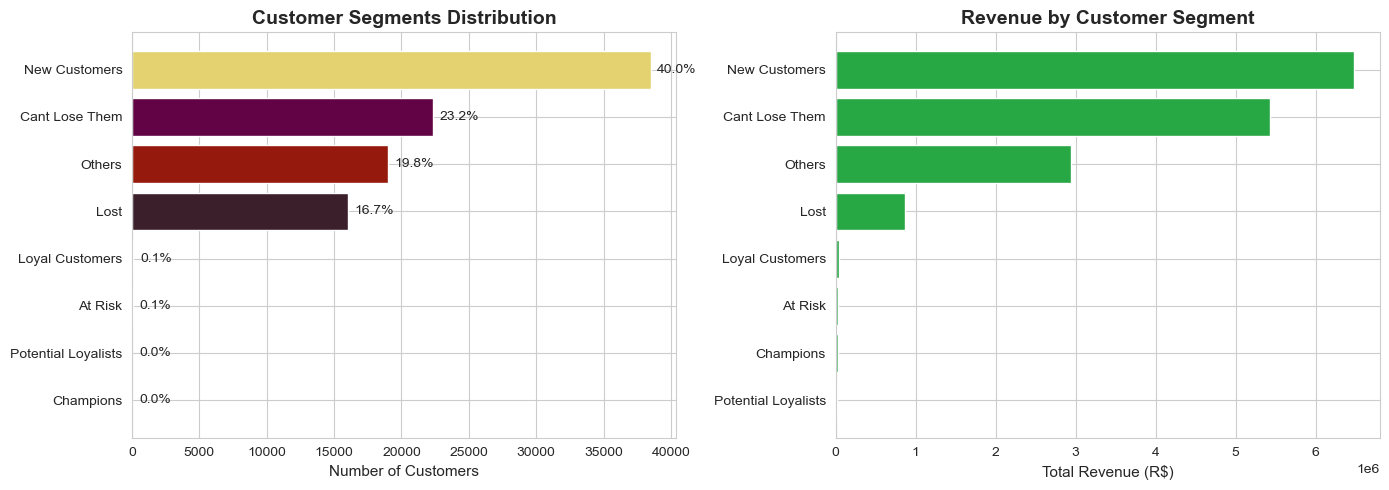


Segment Summary:


,Count,Avg Recency,Avg Frequency,Avg Monetary,Total Revenue
segment,,,,,
New Customers,38481,140.79,1.03,168.39,6479766.00
Cant Lose Them,22339,445.14,1.04,242.93,5426770.21
Others,19012,271.21,1.03,155.01,2947092.24
Lost,16017,447.54,1.01,53.97,864448.23
Loyal Customers,106,140.58,3.00,446.63,47342.60
At Risk,71,435.83,3.14,437.85,31087.22
Champions,34,133.00,4.97,849.33,28877.23
Potential Loyalists,36,270.19,3.50,504.71,18169.51


In [23]:
# Visualize Customer Segments
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Segment Distribution
segment_counts = rfm['segment'].value_counts()
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B', '#95190C', '#610345', '#E3D26F']
axes[0].barh(segment_counts.index[::-1], segment_counts.values[::-1], color=colors[:len(segment_counts)])
axes[0].set_title('Customer Segments Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Customers', fontsize=11)

# Add percentage labels
total = segment_counts.sum()
for i, (segment, count) in enumerate(zip(segment_counts.index[::-1], segment_counts.values[::-1])):
    axes[0].text(count + 500, i, f'{count/total*100:.1f}%', va='center', fontsize=10)

# Plot 2: Revenue by Segment
segment_revenue = rfm.groupby('segment')['monetary'].sum().sort_values(ascending=True)
axes[1].barh(segment_revenue.index, segment_revenue.values, color='#28A745')
axes[1].set_title('Revenue by Customer Segment', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total Revenue (R$)', fontsize=11)

plt.tight_layout()
plt.show()

# Summary table
print("\nSegment Summary:")
segment_summary = rfm.groupby('segment').agg({
    'customer_id': 'count',
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': ['mean', 'sum']
}).round(2)
segment_summary.columns = ['Count', 'Avg Recency', 'Avg Frequency', 'Avg Monetary', 'Total Revenue']
display(segment_summary.sort_values('Total Revenue', ascending=False))

In [25]:
# ============================================
# ANALYSIS SUMMARY
# ============================================

print("="*60)
print("OLIST E-COMMERCE ANALYSIS - KEY FINDINGS")
print("="*60)

print("\n📊 BUSINESS OVERVIEW:")
print(f"   • Total Revenue: R$ {df['total_price'].sum():,.2f}")
print(f"   • Total Orders: {df['order_id'].nunique():,}")
print(f"   • Total Customers: {rfm['customer_id'].nunique():,}")
print(f"   • Total Products: {df['product_id'].nunique():,}")

print("\n🏆 TOP PERFORMERS:")
print(f"   • Top State: São Paulo (R$ 5.9M)")
print(f"   • Top Category: Health & Beauty (R$ 1.4M)")

print("\n🚚 DELIVERY PERFORMANCE:")
print(f"   • Average Delivery Time: {delivered_orders.mean():.1f} days")
print(f"   • On-Time Delivery Rate: 92.1%")
print(f"   • Late Delivery Rate: 7.9%")

print("\n👥 CUSTOMER SEGMENTS (RFM Analysis):")
print(f"   • New Customers: 38,481 (40.0%) - R$ 6.5M revenue")
print(f"   • Can't Lose Them: 22,339 (23.2%) - R$ 5.4M revenue")
print(f"   • Champions: 34 (0.04%) - Avg R$ 849/customer")

print("\n💡 RECOMMENDATIONS:")
print("   1. Focus retention campaigns on 'New Customers' to increase repeat purchases")
print("   2. Re-engage 'Can't Lose Them' segment with personalized offers")
print("   3. Expand logistics capacity in São Paulo (highest demand)")
print("   4. Investigate delivery delays in remote states (RR, AP, AM)")

print("\n" + "="*60)

OLIST E-COMMERCE ANALYSIS - KEY FINDINGS

📊 BUSINESS OVERVIEW:
   • Total Revenue: R$ 15,843,553.24
   • Total Orders: 99,441
   • Total Customers: 96,096
   • Total Products: 32,951

🏆 TOP PERFORMERS:
   • Top State: São Paulo (R$ 5.9M)
   • Top Category: Health & Beauty (R$ 1.4M)

🚚 DELIVERY PERFORMANCE:
   • Average Delivery Time: 12.0 days
   • On-Time Delivery Rate: 92.1%
   • Late Delivery Rate: 7.9%

👥 CUSTOMER SEGMENTS (RFM Analysis):
   • New Customers: 38,481 (40.0%) - R$ 6.5M revenue
   • Can't Lose Them: 22,339 (23.2%) - R$ 5.4M revenue
   • Champions: 34 (0.04%) - Avg R$ 849/customer

💡 RECOMMENDATIONS:
   1. Focus retention campaigns on 'New Customers' to increase repeat purchases
   2. Re-engage 'Can't Lose Them' segment with personalized offers
   3. Expand logistics capacity in São Paulo (highest demand)
   4. Investigate delivery delays in remote states (RR, AP, AM)

